In [48]:
import pandas as pd
from sklearn.model_selection import train_test_split

from dateutil.parser import parse
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

from datetime import datetime as dt
import numpy as np
import math
from sklearn import preprocessing

# Resource
# https://www.machinelearningplus.com/time-series/time-series-analysis-python/

In [49]:
df = pd.read_csv("Electric_Production.csv", parse_dates=['DATE'])

In [50]:
df['DATE'].dtypes

dtype('<M8[us]')

In [51]:
df.head()

,DATE,Value
0,1985-01-01,72.5052
1,1985-02-01,70.6720
2,1985-03-01,62.4502
3,1985-04-01,57.4714
4,1985-05-01,55.3151


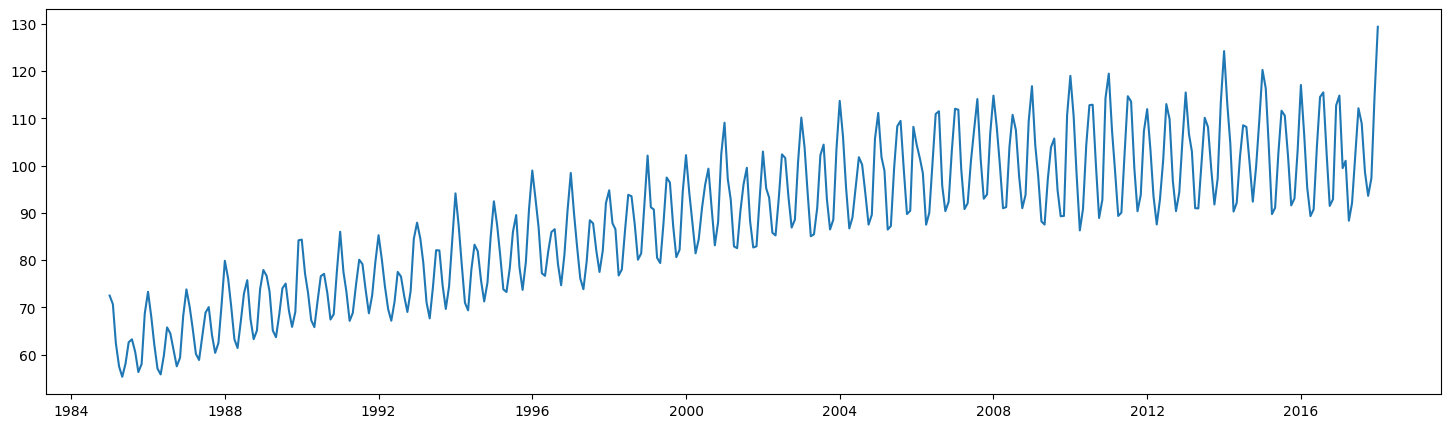

In [52]:
# Plot initial graph
x = df["DATE"]
y = df["Value"]
plt.rcParams["figure.figsize"] = (18,5)
plt.plot(x,y)
plt.show()

In [53]:
# Check for nulls
df.isna().sum()

DATE     0
Value    0
dtype: int64

In [54]:
df.describe()

,DATE,Value
count,397,397.000000
mean,2001-07-01 13:25:14.357682,88.847218
min,1985-01-01 00:00:00,55.315100
25%,1993-04-01 00:00:00,77.105200
50%,2001-07-01 00:00:00,89.779500
75%,2009-10-01 00:00:00,100.524400
max,2018-01-01 00:00:00,129.404800
std,NaN,15.387834


In [55]:
# Multiplicative Decomposition
df = pd.read_csv("Electric_Production.csv", parse_dates=['DATE'], index_col='DATE')

result_mul = seasonal_decompose(df['Value'], model='multiplicative', extrapolate_trend='freq')

In [56]:
# Additive Decomposition
result_add = seasonal_decompose(df['Value'], model='additive', extrapolate_trend='freq')

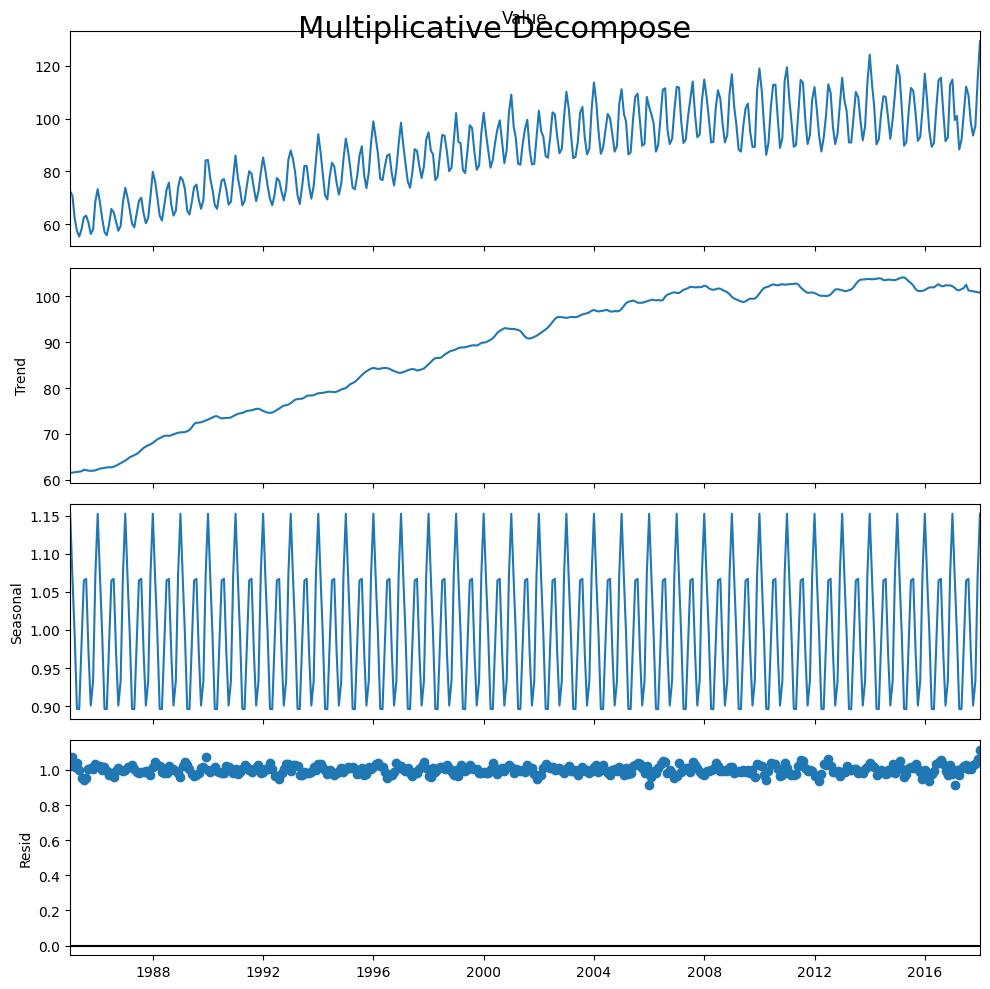

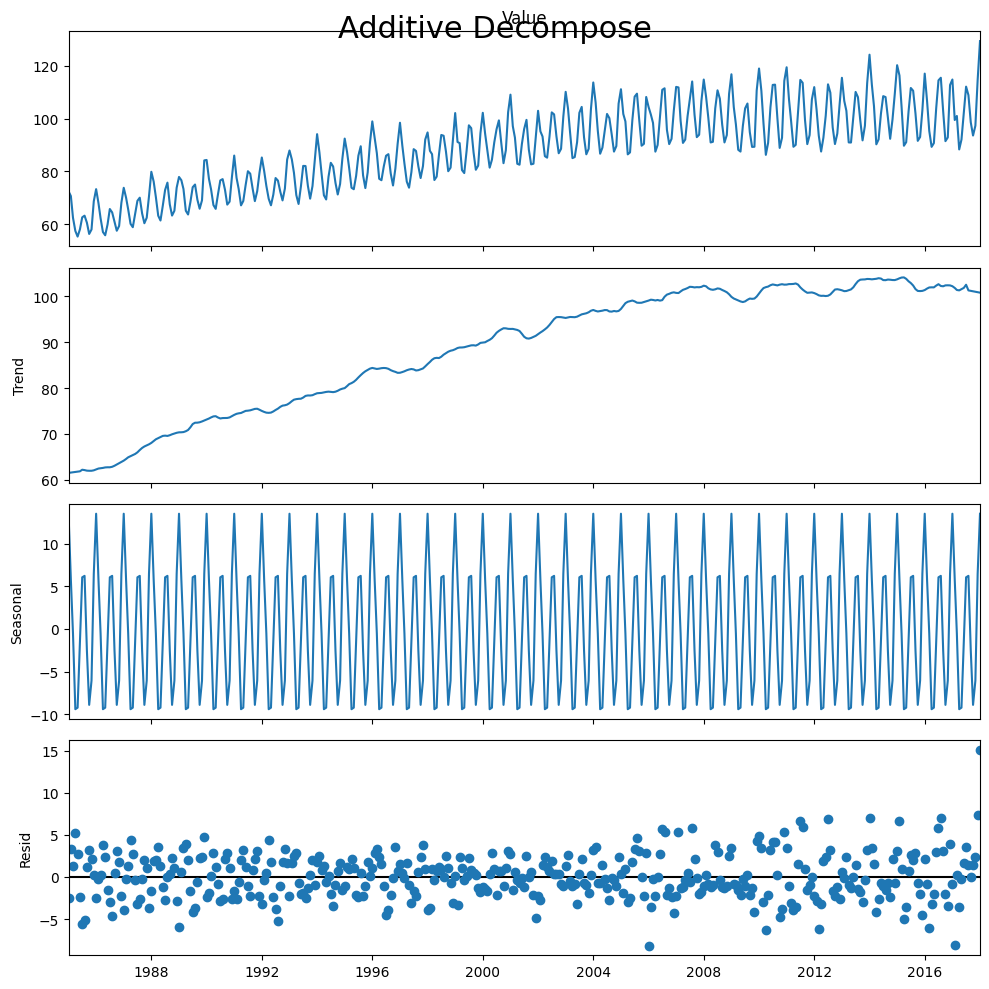

In [57]:
#Plot

plt.rcParams.update({'figure.figsize': (10,10)})
result_mul.plot().suptitle('Multiplicative Decompose', fontsize=22)

result_add.plot().suptitle('Additive Decompose', fontsize=22)
plt.show()

In [58]:
# Extract Components 
# Actual Values = Product of (Seasonal * Trend * Resid)
df_reconstructed = pd.concat([result_mul.seasonal, result_mul.trend, result_mul.resid, result_mul.observed], axis=1)
df_reconstructed.columns = ['seas', 'trend', 'resid', 'actual_values']
df_reconstructed.head()


,seas,trend,resid,actual_values
DATE,,,,
1985-01-01,1.152903,61.508657,1.022446,72.5052
1985-02-01,1.067341,61.577679,1.075279,70.6720
1985-03-01,0.995556,61.646701,1.017556,62.4502
1985-04-01,0.896242,61.715723,1.039036,57.4714
1985-05-01,0.895830,61.784745,0.999395,55.3151


In [59]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [60]:
# Model fit
model = SARIMAX(df, order=(1, 1, 1), seasonal_order=(1,1,1,12))
model_fit = model.fit(disp=False)

c:\Users\amitb\OneDrive\Desktop\project chirraag\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\amitb\OneDrive\Desktop\project chirraag\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [61]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Value   No. Observations:                  397
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -888.613
Date:                            Tue, 17 Mar 2026   AIC                           1787.226
Time:                                    07:19:05   BIC                           1806.979
Sample:                                01-01-1985   HQIC                          1795.061
                                     - 01-01-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5249      0.045     11.764      0.000       0.437       0.612
ma.L1         -0.9547      0.018    -54.378      0.000      -0.989      -0.920
ar.S.L12       0.0417      0.057      0.727      0.467      -0.071       0.154
ma.S.L12      -0.7688      0.045    -17.104      0.000      -0.857      -0.681
sigma2         5.8004      0.341     16.998      0.000       5.132       6.469
===================================================================================
Ljung-Box (L1) (Q):                   0.23   Jarque-Bera (JB):                27.47
Prob(Q):                              0.63   Prob(JB):                         0.00
Heteroskedasticity (H):               3.01   Skew:                            -0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [62]:
# Create a list and append it with the predicted data
# Prediction list ko reset karein
prediction = []

# Agle 12 months predict karne ke liye
forecast = model_fit.forecast(steps=12)

# Forecasted values ko list mein append karein
for date, value in forecast.items():
    prediction.append([date, value])
    print(f"Date: {date}, Predicted Value: {value}")

Date: 2018-02-01 00:00:00, Predicted Value: 114.0114101064714
Date: 2018-03-01 00:00:00, Predicted Value: 105.12219509225572
Date: 2018-04-01 00:00:00, Predicted Value: 92.71432815366913
Date: 2018-05-01 00:00:00, Predicted Value: 94.15940332202591
Date: 2018-06-01 00:00:00, Predicted Value: 104.62173505376254
Date: 2018-07-01 00:00:00, Predicted Value: 113.8615975802389
Date: 2018-08-01 00:00:00, Predicted Value: 112.60892375247995
Date: 2018-09-01 00:00:00, Predicted Value: 101.9319206535441
Date: 2018-10-01 00:00:00, Predicted Value: 93.99736266578678
Date: 2018-11-01 00:00:00, Predicted Value: 97.27117950395737
Date: 2018-12-01 00:00:00, Predicted Value: 112.65171882902224
Date: 2019-01-01 00:00:00, Predicted Value: 122.51402092464704


In [63]:
yhat.index[0]

Timestamp('2018-01-01 00:00:00')

In [64]:
print(prediction)

[[Timestamp('2018-02-01 00:00:00'), 114.0114101064714], [Timestamp('2018-03-01 00:00:00'), 105.12219509225572], [Timestamp('2018-04-01 00:00:00'), 92.71432815366913], [Timestamp('2018-05-01 00:00:00'), 94.15940332202591], [Timestamp('2018-06-01 00:00:00'), 104.62173505376254], [Timestamp('2018-07-01 00:00:00'), 113.8615975802389], [Timestamp('2018-08-01 00:00:00'), 112.60892375247995], [Timestamp('2018-09-01 00:00:00'), 101.9319206535441], [Timestamp('2018-10-01 00:00:00'), 93.99736266578678], [Timestamp('2018-11-01 00:00:00'), 97.27117950395737], [Timestamp('2018-12-01 00:00:00'), 112.65171882902224], [Timestamp('2019-01-01 00:00:00'), 122.51402092464704]]


In [65]:
# Electric Production Prediction table for year 2018
df2 = pd.DataFrame(prediction, columns = ['DATE', 'Value'])
display(df2)

,DATE,Value
0,2018-02-01,114.011410
1,2018-03-01,105.122195
2,2018-04-01,92.714328
3,2018-05-01,94.159403
4,2018-06-01,104.621735
5,2018-07-01,113.861598
6,2018-08-01,112.608924
7,2018-09-01,101.931921
8,2018-10-01,93.997363
9,2018-11-01,97.271180


In [66]:
df2['DATE'].dtypes

dtype('<M8[us]')

In [67]:
df = df.reset_index()
df

,DATE,Value
0,1985-01-01,72.5052
1,1985-02-01,70.6720
2,1985-03-01,62.4502
3,1985-04-01,57.4714
4,1985-05-01,55.3151
...,...,...
392,2017-09-01,98.6154
393,2017-10-01,93.6137
394,2017-11-01,97.3359
395,2017-12-01,114.7212


In [68]:
result = pd.concat([df, df2], ignore_index=True, axis = 0)

In [69]:
result

,DATE,Value
0,1985-01-01,72.505200
1,1985-02-01,70.672000
2,1985-03-01,62.450200
3,1985-04-01,57.471400
4,1985-05-01,55.315100
...,...,...
404,2018-09-01,101.931921
405,2018-10-01,93.997363
406,2018-11-01,97.271180
407,2018-12-01,112.651719


In [70]:
df_predicted = pd.DataFrame(data=result)
df_predicted

,DATE,Value
0,1985-01-01,72.505200
1,1985-02-01,70.672000
2,1985-03-01,62.450200
3,1985-04-01,57.471400
4,1985-05-01,55.315100
...,...,...
404,2018-09-01,101.931921
405,2018-10-01,93.997363
406,2018-11-01,97.271180
407,2018-12-01,112.651719


In [71]:
x2 = df2["DATE"]
y2 = df2["Value"]

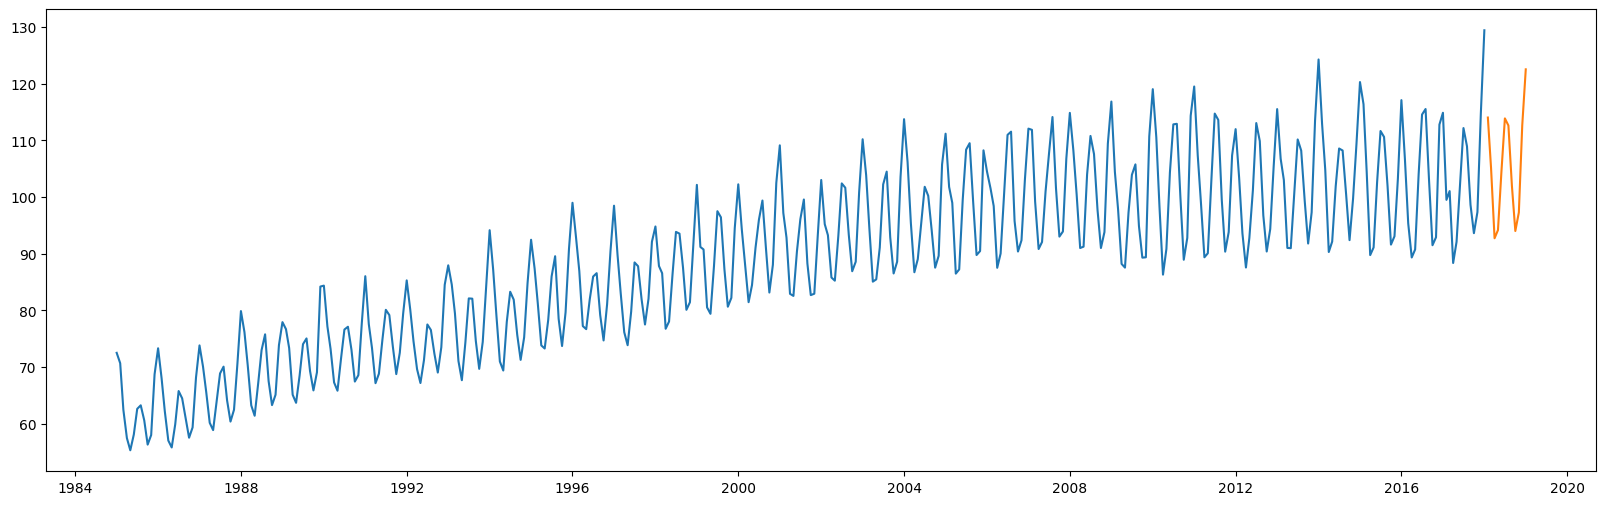

In [72]:
# Final Prediction Graph
#Predicted part colored in orange
plt.rcParams["figure.figsize"] = (20,6)
plt.plot(x,y)
plt.plot(x2,y2)

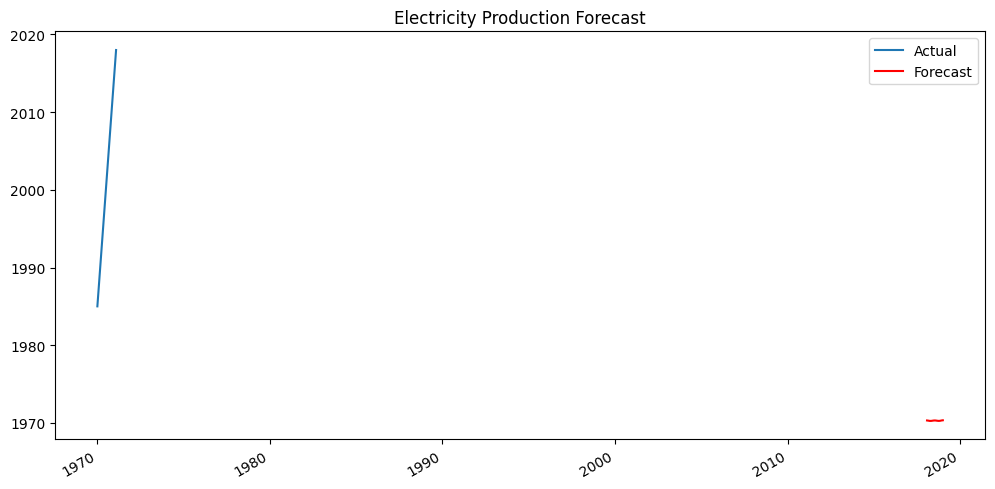

In [73]:
import matplotlib.pyplot as plt

# Original data plot karein
plt.figure(figsize=(12,6))
plt.plot(df.index, df.iloc[:,0], label='Actual')

# Predicted data plot karein
forecast.plot(label='Forecast', color='red')

plt.title('Electricity Production Forecast')
plt.legend()
plt.show()

In [74]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Agar aapke paas test data hai, toh accuracy aise nikalegi:
rmse = np.sqrt(mean_squared_error(df.iloc[-12:, 0], forecast))
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 1500269955286822.5


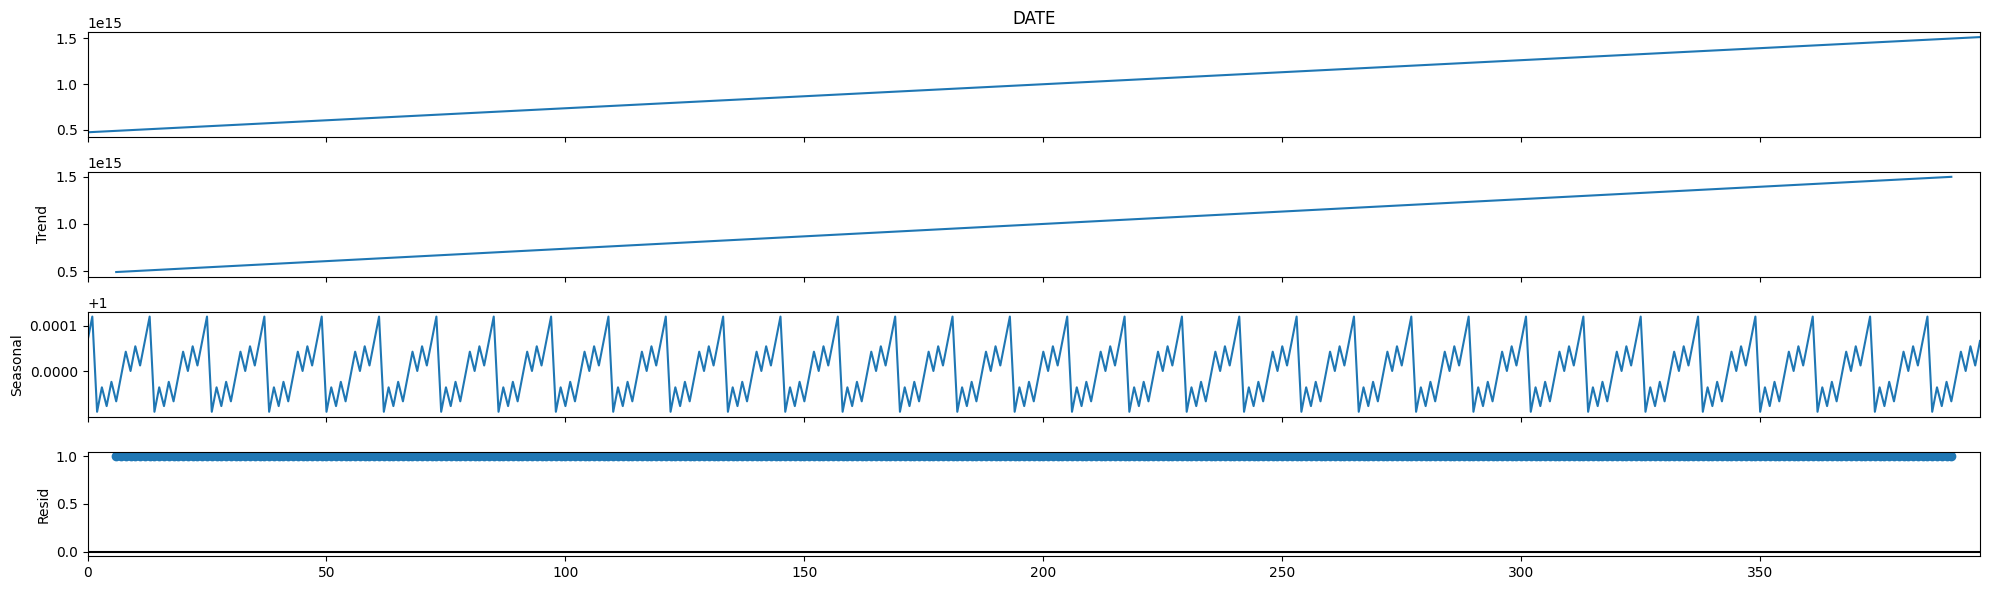

In [75]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df.iloc[:,0], model='multiplicative', period=12)
result.plot()
plt.show()